# Module 10: MBS & Prepayment Verification

## PSA Prepayment Models

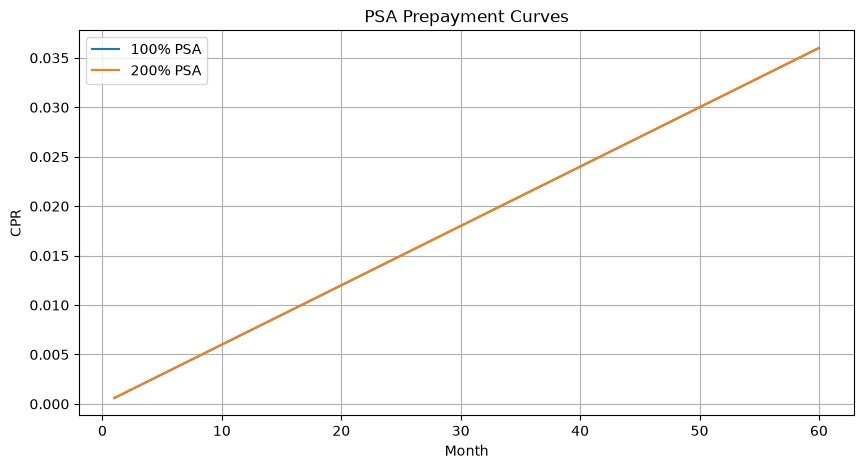

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from src.mbs.prepayment import cpr_to_smm, psa_to_cpr  # noqa: E402
from src.mbs.pass_through import project_cash_flows  # noqa: E402
import matplotlib.pyplot as plt

# PSA Model
months = np.arange(1, 61)
cpr_100 = [psa_to_cpr(m, 100) for m in months]
cpr_200 = [psa_to_cpr(m, 200) for m in months]

plt.figure(figsize=(10, 5))
plt.plot(months, cpr_100, label="100% PSA")
plt.plot(months, cpr_200, label="200% PSA")
plt.title("PSA Prepayment Curves")
plt.xlabel("Month")
plt.ylabel("CPR")
plt.legend()
plt.grid(True)
plt.show()

## Pass-Through Cash Flows

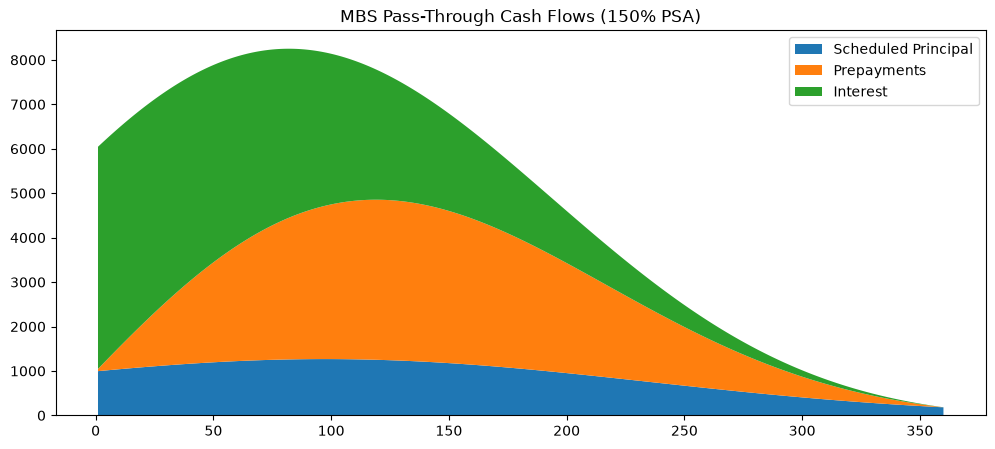

In [2]:
# Pass-Through Cash Flows
balance = 1_000_000
wac = 0.06  # Weighted Average Coupon
term = 360  # 30-year
cpr_curve = [psa_to_cpr(m, 150) for m in range(1, term + 1)]
smm_curve = [cpr_to_smm(cpr) for cpr in cpr_curve]

cashflows = project_cash_flows(balance, wac, term, smm_curve)

# Plot Cashflows
plt.figure(figsize=(12, 5))
plt.stackplot(
    range(1, term + 1),
    cashflows["scheduled_principal"],
    cashflows["prepayment"],
    cashflows["interest"],
    labels=["Scheduled Principal", "Prepayments", "Interest"],
)
plt.legend(loc="upper right")
plt.title("MBS Pass-Through Cash Flows (150% PSA)")
plt.show()